In [1]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-6vd5m7fa
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-6vd5m7fa
  Resolved https://www.github.com/mouseland/cellpose.git to commit 71e7e887216c36d06f01ca3e9958a06949980d90
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 141.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 80.3 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.2.dev16+g71e7e8872-py3-none-any.whl size=214482 sha256=7075d134ebb20fdac341d57c62144ab8ddeeacd6fd2f5f79e093dfb3c51766ef
  Stored in directory: /tmp/pip-ephem-wheel-cache-djlq_hoc/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
  Preparing metadata (setup.py) ... done


In [1]:
import owncloud, getpass, cellpose

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [3]:
oc.upload_data()

In [2]:
oc.upload_scripts()

In [3]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tool
import pandas as pd


from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [6]:

oc.upload_models()

In [4]:
import json

with open('./data/dataset_splits_3D_annotations_actuelles.json', 'r') as f:
    splits = json.load(f)

ids_test  = splits['test']

print(f"Splits chargés : Test({len(ids_test)})")

Splits chargés : Test(13)


In [5]:
df_annotations = pd.read_csv('./data/Nuclei.csv')

Visualisation de l'image 325 avec ses annotations et sa segmentation SB


TypeError: CellVisualizer.load_data() got an unexpected keyword argument 'mode'

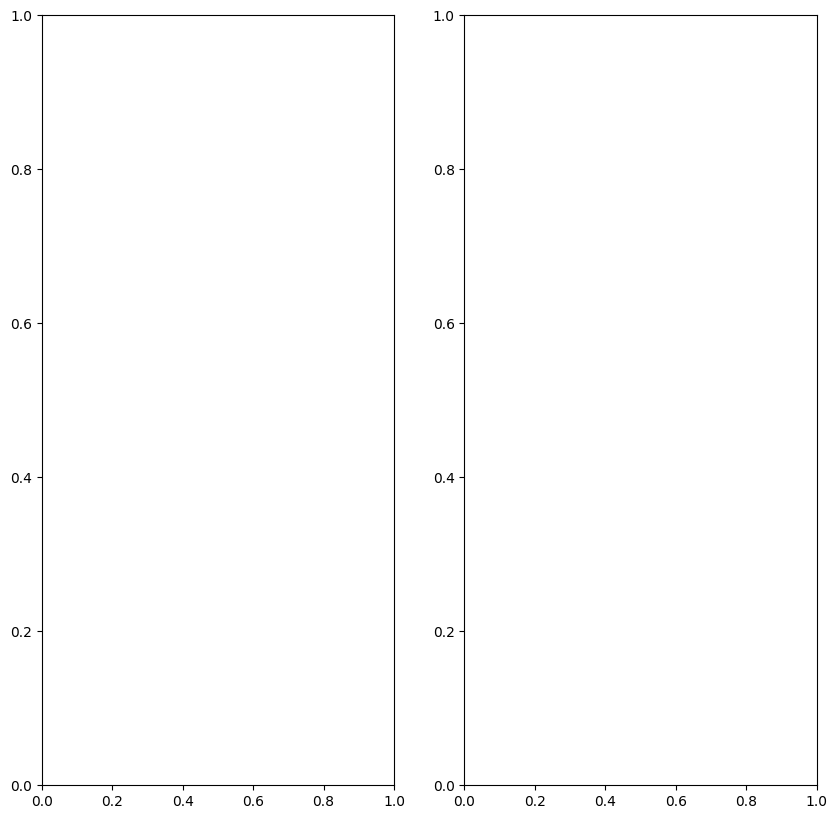

In [11]:
img_id = ids_test[12]
print(f"Visualisation de l'image {img_id} avec ses annotations et sa segmentation SB")  

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 10))
visualizer.plot_points_overlay(img_id, df_annotations, ax=ax1, show=False, prediction=False, annotation=True)
visualizer.plot(i=img_id, target= 'Image', ax=ax2, show=False)
ax1.axis('off')
ax2.axis('off')
plt.show()  

In [6]:

from io import StringIO 
from contextlib import redirect_stdout

label = "Nuclei_cellpose4_stack"
target = "Nuc"
load_method = "data"
mode = "Image"
param = {"channels": [0, 0], "flow_threshold": 0.4, "cellprob_threshold": -0.5}
model_path = "./models/cellpose4_nuclei_stack.pth"

# Initialisation
ev = tool.Stats() # Assurez-vous que compute_points_metrics est bien dans cette classe
base_output = os.path.abspath("./results/benchmark_SB")
model_root = os.path.join(base_output, label)
output_dir_masks = os.path.join(model_root, "masks")
output_dir_viz = os.path.join(model_root, "viz")

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

model = models.CellposeModel(gpu=True, pretrained_model=model_path)

all_results = []

if load_method == "channel":
    X_val_multi, _ = visualizer.load_channel(ids_test, target=mode)

# --- 1. INFERENCE ET CALCUL DES METRIQUES ---
for idx, img_id in enumerate(ids_test):
    # Chargement de l'image uniquement
    if load_method == "channel":
        img = X_val_multi[idx]
    else:
        img = visualizer.load_data(img_id, target=mode)

    # Inférence
    masks, _, _ = model.eval(img, **param)

    # Sauvegarde du masque
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_{target}_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    
    # ÉVALUATION : Appel corrigé avec les bons paramètres
    perf = ev.compute_points_metrics(img_id, masks, df_annotations)
    all_results.append(perf)

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    ax1, ax2 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title(f"A. Image Entrée ")

    visualizer.plot_points_overlay(img_id, df_annotations, mask_pred=masks, ax=ax2, show=False, prediction=True, annotation=True)
    ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
    
    titre_rapport = (f"Rapport Image : {img_id} | F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_viz.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    plt.close(fig)

#rapport final
f = StringIO()
with redirect_stdout(f):
    df_final = ev.global_report_point(all_results, model_name=label)
rapport_texte = f.getvalue()

print(rapport_texte)

chemin_txt = os.path.join(model_root, f"resultats_globaux_{label}.txt")
with open(chemin_txt, "w") as text_file:
    text_file.write(rapport_texte)

plt.close('all')

# export
print("\nExportation de l'intégralité du dossier benchmark...")
try:
    chemin_export_global = "/travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test_SB_stack"
    oc.download_path(base_output, chemin_export_global)
    print(f"Export réussi vers : {chemin_export_global}")
except Exception as e:
    print(f"Erreur lors de l'export global : {e}")

print(f"\nÉvaluation terminée. Tous les résultats sont sauvegardés dans : {base_output}")


RESULTATS GLOBAUX : Nuclei_cellpose4_stack
Images evaluees          : 13
Total Vrais Positifs (TP): 787
Total Faux Positifs (FP) : 423
Total Faux Negatifs (FN) : 398
--------------------------------------------------
F1-Score Global (Micro)  : 0.657
F1-Score Moyen (Macro)   : 0.633



Exportation de l'intégralité du dossier benchmark...
Dossier benchmark_SB envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test_SB_stack.zip
Export réussi vers : /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test_SB_stack

Évaluation terminée. Tous les résultats sont sauvegardés dans : /content/results/benchmark_SB


In [7]:
chemin_export_global = "/travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test"
oc.download_path(base_output, chemin_export_global)

Dossier benchmark_SB envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/benchmark_test.zip
